<a href="https://colab.research.google.com/github/AbouCamara/IA-FORCE-N/blob/main/prediction_prix_ordinateurs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [67]:
#  1. Importation des librairies
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib


In [68]:
#  2. Chargement et aperçu du jeu de données
df = pd.read_csv("/content/laptop_data.csv")
df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1303 entries, 0 to 1302
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        1303 non-null   int64  
 1   Company           1303 non-null   object 
 2   TypeName          1303 non-null   object 
 3   Inches            1303 non-null   float64
 4   ScreenResolution  1303 non-null   object 
 5   Cpu               1303 non-null   object 
 6   Ram               1303 non-null   object 
 7   Memory            1303 non-null   object 
 8   Gpu               1303 non-null   object 
 9   OpSys             1303 non-null   object 
 10  Weight            1303 non-null   object 
 11  Price             1303 non-null   float64
dtypes: float64(2), int64(1), object(9)
memory usage: 122.3+ KB


,Unnamed: 0,Inches,Price
count,1303.00000,1303.000000,1303.000000
mean,651.00000,15.017191,59870.042910
std,376.28801,1.426304,37243.201786
min,0.00000,10.100000,9270.720000
25%,325.50000,14.000000,31914.720000
50%,651.00000,15.600000,52054.560000
75%,976.50000,15.600000,79274.246400
max,1302.00000,18.400000,324954.720000


In [71]:
#   3. Nettoyage et prétraitement
# - Valeurs manquantes
# - Anomalies
# - Transformation de variables (encodage, normalisation, etc.)

df.isnull().sum()
# Exemple de remplacement
# Convertir la colonne « Ram » en valeur numérique en supprimant « Go » et en la convertissant en entiers
# S'assurer que la colonne « Ram » est traitée comme une chaîne avant d'appliquer .str.replace
df['Ram'] = df['Ram'].astype(str).str.replace('GB', '').astype(int)
df['Ram'] = df['Ram'].fillna(df['Ram'].median())

<Axes: xlabel='Price', ylabel='Count'>

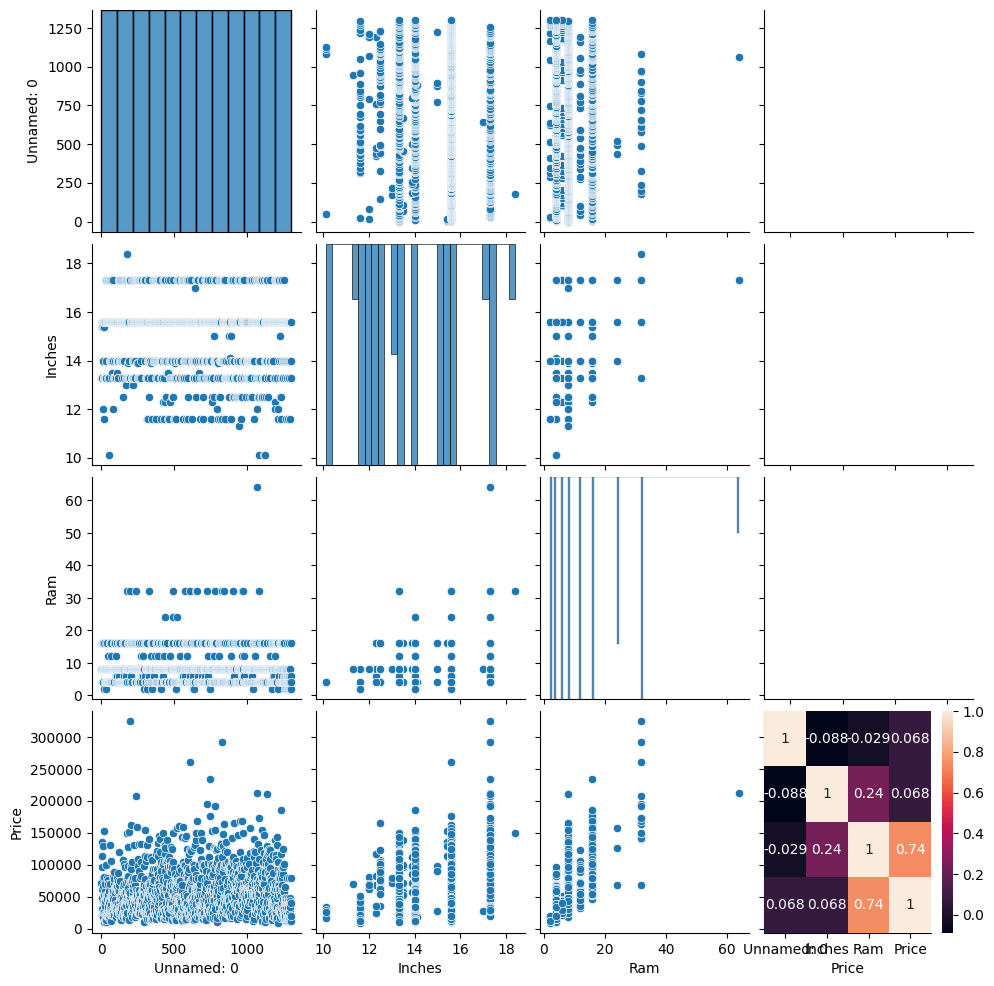

In [72]:
#  4. Analyse exploratoire
sns.pairplot(df)
# Sélectionnez uniquement les caractéristiques numériques pour l'analyse de corrélation
numerical_df = df.select_dtypes(include=np.number)
sns.heatmap(numerical_df.corr(), annot=True)
# Visualisation de la distribution des prix
# Vérifiez si le nom de la colonne est « Prix » au lieu de « prix »
sns.histplot(df['Price'], kde=True) # Remplacement de « price » par « Prix »

In [73]:
# 5. Sélection des variables/caractéristiques
#Exemple :
# Obtenez les noms de colonnes réels
print(df.columns)

# Utilisez les noms de colonnes réels, en corrigeant la casse ou les fautes de frappe
X = df[['Ram', 'Gpu', 'Inches', 'Company']]  # Noms de colonnes corrigés pour correspondre aux noms réels dans df
y = df['Price']  # Nom de colonne mis à jour

# Encodage si besoin
X = pd.get_dummies(X, drop_first=True)

Index(['Unnamed: 0', 'Company', 'TypeName', 'Inches', 'ScreenResolution',
       'Cpu', 'Ram', 'Memory', 'Gpu', 'OpSys', 'Weight', 'Price'],
      dtype='object')


In [74]:
X = df.drop("Price", axis=1)  # ou "prix"
X = pd.get_dummies(X)
y = df["Price"]

In [75]:
# 6. Division des données
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [76]:
# 7. Entraînement du modèle
model = LinearRegression()
model.fit(X_train, y_train)


LinearRegression()

In [77]:
# 8. Évaluation du modèle
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²: {r2:.2f}")


MAE: 10996.96
RMSE: 16790.43
R²: 0.80


In [78]:
# 9. Sauvegarde du modèle
joblib.dump(model, "modele.pkl")

# Important : sauvegarder les colonnes utilisées !
joblib.dump(X.columns.tolist(), "colonnes.pkl")

# Charger le modèle
loaded_model = joblib.load('modele.pkl')
